In [6]:
# === 準備1: torchaudio 互換パッチ（pyannote 3.x が期待する古いAPIを生やす）===
import sys, types, torchaudio
 
# 廃止済み関数をダミー実装    
def _noop(*a, **k): pass
if not hasattr(torchaudio, "set_audio_backend"):
    torchaudio.set_audio_backend = _noop
if not hasattr(torchaudio, "get_audio_backend"):
    torchaudio.get_audio_backend = lambda: "soundfile"
if not hasattr(torchaudio, "list_audio_backends"):
    torchaudio.list_audio_backends = lambda: ["soundfile"]
torchaudio.set_audio_backend("soundfile")

# なくなったモジュールパス torchaudio.backend.common を作って、AudioMetaData を割り当て
mod_backend = types.ModuleType("torchaudio.backend")
mod_common  = types.ModuleType("torchaudio.backend.common")
try:
    from torchaudio import AudioMetaData as _AMD   # 2.x ではここにある
except Exception:
    class _AMD:                                    # 念のための空クラス
        pass
mod_common.AudioMetaData = _AMD
sys.modules["torchaudio.backend"] = mod_backend
sys.modules["torchaudio.backend.common"] = mod_common

# === 追加: torchaudio.info 互換ダミー（soundfile で代用）===
import soundfile as sf
if not hasattr(torchaudio, "info"):
    def _info(path):
        try:
            f = sf.SoundFile(path)
            sr = f.samplerate
            frames = len(f)
            channels = f.channels
            f.close()
            class Info:
                sample_rate = sr
                num_channels = channels
                num_frames = frames
            return Info()
        except Exception as e:
            raise RuntimeError(f"torchaudio.info fallback failed for {path}: {e}")
    torchaudio.info = _info


In [7]:
# === 準備2: pyannote パイプライン ===
from pyannote.audio import Pipeline

# ※ トークンは環境変数化推奨（HF_TOKEN など）
pipe = Pipeline.from_pretrained(
    "pyannote/speaker-diarization-3.1",
    use_auth_token=__import__("os").environ["HF_TOKEN"]
)
# GPU使えるなら
# pipe = pipe.to("cuda")

print("pipeline ready ✓")


pipeline ready ✓


In [3]:
# === Block A: 比較対象の設定 ===
from pathlib import Path
# 2つのWAVファイルのパスを指定
WAV_IDEAL = "/root/MedWhisper/202502/右後ろ_1回目.wav"
WAV_NOISY = "/root/MedWhisper/0604data/1回目_右後ろ.wav"

# Pathオブジェクトとして扱う
path_ideal = Path(WAV_IDEAL)
path_noisy = Path(WAV_NOISY)

print(f"理想環境 (Ideal): {path_ideal.name}")
print(f"実用環境 (Noisy): {path_noisy.name}")

理想環境 (Ideal): 右後ろ_1回目.wav
実用環境 (Noisy): 1回目_右後ろ.wav


In [4]:
# === Required Functions (Add this to your notebook) ===
import pyloudnorm as pyln
import librosa
import numpy as np

def lufs(x, sr):
    """Calculates the integrated loudness in LUFS."""
    meter = pyln.Meter(sr)
    return meter.integrated_loudness(x)

def ltas_db(x, sr, n_fft=2048, hop=512):
    """Calculates the Long-Term Average Spectrum in dB."""
    S = np.abs(librosa.stft(x, n_fft=n_fft, hop_length=hop)).mean(axis=1)
    f = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    return f, 20 * np.log10(S + 1e-12)

print("Helper functions are now defined and ready to use!")

# === Block B: 比較分析の実行 ===
import pandas as pd

def analyze_audio_characteristics(wav_path):
    """指定されたWAVファイルを多角的に分析する関数"""
    y, sr = librosa.load(wav_path, sr=16000, mono=True)
    
    # 基本メトリクス
    metrics = {
        "LUFS": lufs(y, sr),
        "Peak": np.max(np.abs(y)),
    }
    
    # ノイズフロアの推定 (エネルギーが低いフレーム10%の平均RMS)
    E = librosa.feature.rms(y=y, frame_length=2048, hop_length=512).squeeze()
    noise_floor_rms = np.percentile(E, 10)
    metrics["Noise Floor (dBFS)"] = 20 * np.log10(noise_floor_rms + 1e-12)

    # 周波数特性 (LTAS)
    f, d = ltas_db(y, sr)
    
    # スペクトログラム
    S_db = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    
    return metrics, (f, d), S_db, sr

# 各ファイルを分析
metrics_ideal, ltas_ideal, spec_ideal, sr_ideal = analyze_audio_characteristics(WAV_IDEAL)
metrics_noisy, ltas_noisy, spec_noisy, sr_noisy = analyze_audio_characteristics(WAV_NOISY)

# 結果をDataFrameで見やすく表示
df = pd.DataFrame({"Ideal": metrics_ideal, "Noisy": metrics_noisy})
print(df)

Helper functions are now defined and ready to use!
                        Ideal      Noisy
LUFS               -34.380215 -35.382228
Peak                 0.424957   0.814575
Noise Floor (dBFS) -52.851939 -46.183940


/tmp/ipykernel_387602/2939110162.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


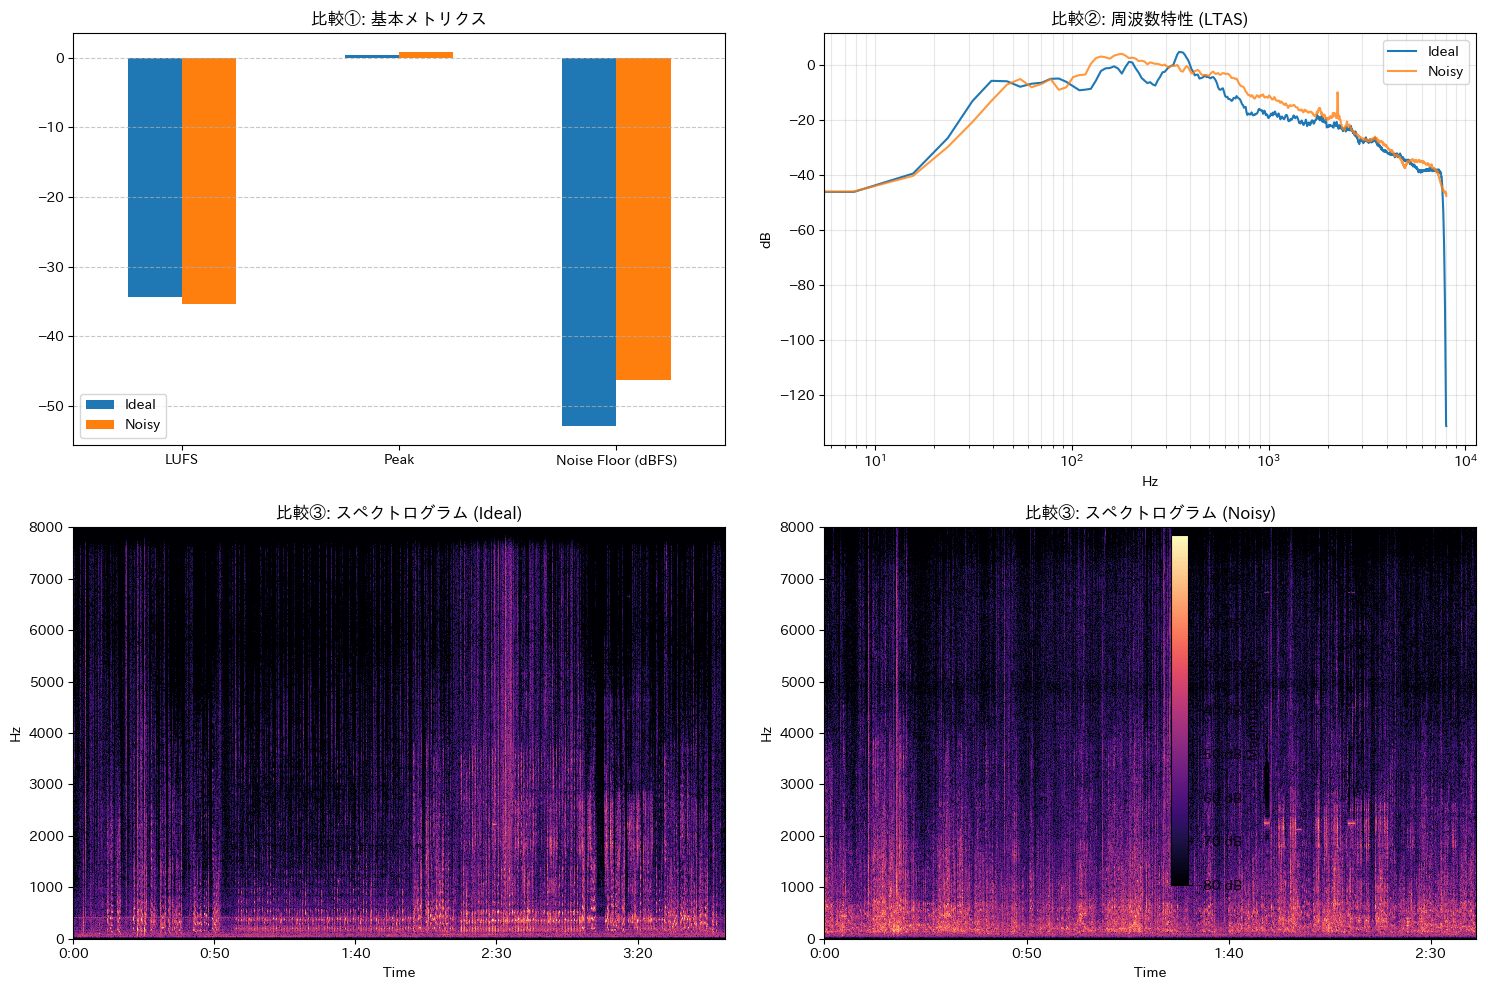

In [5]:
# === Block C: 比較結果の可視化 ===
# === Block 0: 共通ユーティリティ ===
import numpy as np, librosa, soundfile as sf, pyloudnorm as pyln, scipy.signal as sig, matplotlib.pyplot as plt
import japanize_matplotlib
from pathlib import Path

fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2)

# 1. 基本メトリクスの比較 (棒グラフ)
ax1 = fig.add_subplot(gs[0, 0])
df.plot(kind='bar', ax=ax1, rot=0)
ax1.set_title("比較①: 基本メトリクス")
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# 2. 周波数特性の比較 (LTAS)
ax2 = fig.add_subplot(gs[0, 1])
ax2.semilogx(ltas_ideal[0], ltas_ideal[1], label="Ideal")
ax2.semilogx(ltas_noisy[0], ltas_noisy[1], label="Noisy", alpha=0.8)
ax2.set_title("比較②: 周波数特性 (LTAS)")
ax2.set_xlabel("Hz")
ax2.set_ylabel("dB")
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

# 3. スペクトログラムの比較
# 共通のカラースケールを設定
vmin = np.min([spec_ideal.min(), spec_noisy.min()])
vmax = np.max([spec_ideal.max(), spec_noisy.max()])

ax3 = fig.add_subplot(gs[1, 0])
librosa.display.specshow(spec_ideal, sr=sr_ideal, x_axis='time', y_axis='hz', ax=ax3, vmin=vmin, vmax=vmax)
ax3.set_title("比較③: スペクトログラム (Ideal)")

ax4 = fig.add_subplot(gs[1, 1])
img = librosa.display.specshow(spec_noisy, sr=sr_noisy, x_axis='time', y_axis='hz', ax=ax4, vmin=vmin, vmax=vmax)
ax4.set_title("比較③: スペクトログラム (Noisy)")

fig.colorbar(img, ax=[ax3, ax4], format='%+2.0f dB', label='Magnitude (dB)')
plt.tight_layout()
plt.show()

In [20]:
!pip install -U demucs

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.0 MB/s  0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  DEPRECATION: Building 'demucs' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'demucs'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for demucs: filename=demucs-4.0.1-py3-none-any.whl size=78480 sha256=d542c20afcb333a05f91ad3d14f1b7c1a5110c278cf7aae7d0d4d876a18653d0
  Stored in directory: /tmp/pip-ephem-wheel-cache-_q0p07w4/wheels/bb/06/a3/83489d50c9f015fa981a2a7bb08fcede75120a0de56775353f
  Created wheel 

In [25]:
!ffmpeg -version

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-l

In [26]:
# === Block D: AIノイズ除去 (Demucs) ===
import subprocess
from pathlib import Path

# --- 設定 ---
# ノイズ除去を適用したい音声ファイル (実用環境のWAV)
input_file = WAV_NOISY 

# この1行を変更するだけで、すべてのファイルパスが切り替わる
FILE_NAME = "202502/右後ろ_1回目"

# 基本のパスを組み立てる
BASE_DIR = Path("/root/MedWhisper")
WAV      = BASE_DIR / f"{FILE_NAME}.wav"
OUTDIR   = Path(f"./_work/{FILE_NAME}"); OUTDIR.mkdir(exist_ok=True, parents=True)

# 出力先ディレクトリ
output_dir = OUTDIR / "demucs_output"
output_dir.mkdir(exist_ok=True)
# === Block C.5: 音声ファイルのサニタイズ (クリーンアップ) ===
import subprocess
from pathlib import Path

# --- 設定 ---
# クリーンアップしたい音声ファイル
input_to_sanitize = WAV_NOISY 

# 新しいファイル名を作成
sanitized_path = Path(input_to_sanitize).parent / f"{Path(input_to_sanitize).stem}_sanitized.wav"

# --- 実行 ---
print(f"音声ファイルを標準形式に変換（サニタイズ）します...")
print(f"入力: {input_to_sanitize}")
print(f"出力: {sanitized_path}")

try:
    # ffmpegコマンドで、最も標準的な16-bit PCM形式のWAVに変換
    command = [
        "ffmpeg",
        "-i", str(input_to_sanitize), # 入力ファイル
        "-ar", "16000",                # サンプリングレートを16kHzに
        "-ac", "1",                    # チャンネルをモノラルに
        "-c:a", "pcm_s16le",           # 16bit signed-integer PCM形式でエンコード
        "-y",                          # 既に出力ファイルがあっても上書き
        str(sanitized_path)            # 出力ファイル
    ]
    
    # capture_output=Trueでffmpegの出力を非表示にする
    subprocess.run(command, check=True, capture_output=True, text=True)
    
    print("\nサニタイズが完了しました！👍")
    # この後のDemucsで使うために、新しいパスをグローバル変数に保存
    WAV_NOISY_SANITIZED = str(sanitized_path)

except subprocess.CalledProcessError as e:
    print("\nffmpegの実行中にエラーが発生しました。")
    print("エラー詳細:", e.stderr)
except FileNotFoundError:
    print("\nエラー: 'ffmpeg' コマンドが見つかりません。インストールされているか確認してください。")

音声ファイルを標準形式に変換（サニタイズ）します...
入力: /root/MedWhisper/0604data/1回目_右後ろ.wav
出力: /root/MedWhisper/0604data/1回目_右後ろ_sanitized.wav

サニタイズが完了しました！👍


In [30]:
# === 最終版：AIノイズ除去パイプライン (Sanitize + Demucs, robust) ===
import subprocess
from pathlib import Path
import shutil
import glob
import sys

# ---------- 1) 設定 ----------
INPUT_NOISY_WAV = "/root/MedWhisper/0604data/1回目_右後ろ.wav"
INPUT_BASE_DIR  = Path("/root/MedWhisper")
BASE_OUTPUT_DIR = Path("./_work")

# ---------- 2) パス準備 ----------
noisy_file = Path(INPUT_NOISY_WAV)
relative_path = noisy_file.relative_to(INPUT_BASE_DIR)         # 例: 0604data/1回目_右後ろ.wav
output_dir_for_file = BASE_OUTPUT_DIR / relative_path.with_suffix("")  # 例: _work/0604data/1回目_右後ろ
output_dir_for_file.mkdir(parents=True, exist_ok=True)

sanitized_path    = output_dir_for_file / f"{noisy_file.stem}_sanitized.wav"
demucs_output_dir = output_dir_for_file / "demucs_output"
demucs_output_dir.mkdir(exist_ok=True)

print("--- パイプライン設定 ---")
print(f"入力ファイル         : {noisy_file}")
print(f"出力ディレクトリ     : {output_dir_for_file}")
print(f"サニタイズ出力       : {sanitized_path}")
print(f"Demucs 出力ルート    : {demucs_output_dir}")
print("-" * 40)

# ---------- 3) サニタイズ（FFmpeg） ----------
print("\n[1/2] サニタイズ実行 (16kHz, mono, PCM16LE)")
cmd = [
    "ffmpeg", "-hide_banner", "-loglevel", "error",
    "-i", str(noisy_file),
    "-ar", "16000", "-ac", "1", "-c:a", "pcm_s16le",
    "-y", str(sanitized_path)
]
try:
    subprocess.run(cmd, check=True)
    print(" -> OK:", sanitized_path)
except subprocess.CalledProcessError as e:
    print("[ERROR] ffmpeg 失敗")
    sys.exit(1)

# ---------- 4) Demucs（2 stems: vocals / no_vocals） ----------
print("\n[2/2] Demucs 実行（CPU）")
cmd = [
    "python3", "-m", "demucs.separate",
    "--two-stems", "vocals",
    "-n", "htdemucs_ft",
    "-o", str(demucs_output_dir),
    "--device", "cpu",
    str(sanitized_path)  # ★ stemは「*_sanitized」のまま渡す
]
try:
    subprocess.run(cmd, check=True)
except subprocess.CalledProcessError:
    print("[ERROR] Demucs 実行に失敗しました。")
    sys.exit(1)

# ---------- 5) 出力ボーカルを堅牢に探索 ----------
# 公式の出力構成: <out>/<model>/<stem>/vocals.wav
model_dir = demucs_output_dir / "htdemucs_ft"
candidates = list(model_dir.glob("*/vocals.wav"))
if not candidates:
    # 環境差対策で再帰探索（保険）
    candidates = [Path(p) for p in glob.glob(str(model_dir / "**" / "vocals.wav"), recursive=True)]

if not candidates:
    print("\n[ERROR] Demucs の vocals.wav が見つかりません。探索場所:", model_dir.as_posix())
    # ヒント: 実際に出来たファイルを確認
    if model_dir.exists():
        print("存在するパス例（最大20件）：")
        for p in list(model_dir.rglob("*"))[:20]:
            print(" -", p.as_posix())
    sys.exit(1)

vocals_path = candidates[0]
final_clean = output_dir_for_file / f"{noisy_file.stem}_demucs_vocals.wav"
shutil.copy2(vocals_path, final_clean)

print("\n🎉 完了：ノイズ除去済みファイル")
print(" ->", final_clean.as_posix())

# 以降、Whisper などの入力に final_clean を使う


--- パイプライン設定 ---
入力ファイル         : /root/MedWhisper/0604data/1回目_右後ろ.wav
出力ディレクトリ     : _work/0604data/1回目_右後ろ
サニタイズ出力       : _work/0604data/1回目_右後ろ/1回目_右後ろ_sanitized.wav
Demucs 出力ルート    : _work/0604data/1回目_右後ろ/demucs_output
----------------------------------------

[1/2] サニタイズ実行 (16kHz, mono, PCM16LE)
 -> OK: _work/0604data/1回目_右後ろ/1回目_右後ろ_sanitized.wav

[2/2] Demucs 実行（CPU）


Selected model is a bag of 4 models. You will see that many progress bars per track.
Separated tracks will be stored in /root/MedWhisper/_work/0604data/1回目_右後ろ/demucs_output/htdemucs_ft
Separating track _work/0604data/1回目_右後ろ/1回目_右後ろ_sanitized.wav


100%|██████████████████████████████████████████████| 163.79999999999998/163.79999999999998 [01:17<00:00,  2.12seconds/s]
100%|██████████████████████████████████████████████| 163.79999999999998/163.79999999999998 [01:16<00:00,  2.15seconds/s]
100%|██████████████████████████████████████████████| 163.79999999999998/163.79999999999998 [01:15<00:00,  2.16seconds/s]
100%|██████████████████████████████████████████████| 163.79999999999998/163.79999999999998 [01:13<00:00,  2.21seconds/s]
/root/.venv/pyannote311/lib/python3.11/site-packages/torchaudio/__init__.py:178: UserWarning: The 'encoding' parameter is not fully supported by TorchCodec AudioEncoder.
  return save_with_torchcodec(
/root/.venv/pyannote311/lib/python3.11/site-packages/torchaudio/__init__.py:178: UserWarning: The 'bits_per_sample' parameter is not directly supported by TorchCodec AudioEncoder.
  return save_with_torchcodec(



🎉 完了：ノイズ除去済みファイル
 -> _work/0604data/1回目_右後ろ/1回目_右後ろ_demucs_vocals.wav
